In [1]:
import os
import pandas as pd
from deepmreye import analyse, architecture, preprocess, train
from deepmreye.util import data_generator, model_opts, util
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pickle
import nibabel as nib
from tqdm import tqdm

2025-11-17 14:01:57.962020: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-17 14:01:58.018369: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-17 14:01:58.018426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-17 14:01:58.020662: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-17 14:01:58.032319: I tensorflow/core/platform/cpu_feature_guar

In [2]:

def merge_all_runs_with_zero_labels(functional_data, create_if_no_mask=False):
    """
    For every sub-*/run: load mask_{basename}.p, normalize, determine n_trs,
    create zeros (n_trs,10,2) labels, split mask into left/right and save
    combined/left/right datasets via preprocess.save_data().

    Parameters
    ----------
    functional_data : str
        Path containing sub-*/ folders (e.g., '/mnt/.../stroke_nifti/')
    create_if_no_mask : bool
        If True and mask is missing, try to produce a mask from the .nii.gz
        (simple fallback). Default False.
    """
    participants = sorted([d for d in os.listdir(functional_data) if d.startswith("sub-")])
    print(f"🔍 Found {len(participants)} participants in {functional_data}\n")

    for participant in tqdm(participants):
        participant_folder = os.path.join(functional_data, participant)
        if not os.path.isdir(participant_folder):
            print(f"⚠️ Not a folder: {participant_folder}")
            continue

        subj_id = participant.replace("sub-", "")
        # find all runs (NIfTI)
        nii_runs = sorted([f for f in os.listdir(participant_folder) if f.endswith(".nii.gz")])
        if not nii_runs:
            print(f"⚠️ No .nii.gz runs found for {participant}")
            continue

        for run_file in nii_runs:
            base = run_file.replace(".nii.gz", "")  # e.g. sub-PAT026_ses-acute_task-rest_run-0_bold
            mask_name = f"mask_{base}.p"
            mask_path = os.path.join(participant_folder, mask_name)
            nii_path = os.path.join(participant_folder, run_file)

            if not os.path.exists(mask_path):
                msg = f"⚠️ Missing mask for {base} ({mask_name})"
                if create_if_no_mask:
                    # Optional simple fallback: create zero-mask shaped by NIfTI (NOT recommended for QC)
                    try:
                        img = nib.load(nii_path)
                        arr = img.get_fdata()
                        # create a mask-like array with same shape (x,y,z,t)
                        fake_mask = np.zeros_like(arr, dtype=np.float32)
                        pickle.dump(fake_mask, open(mask_path, "wb"))
                        print(f"🛠 Created fallback mask: {mask_path}")
                    except Exception as e:
                        print(msg + f" — fallback failed: {e}")
                        continue
                else:
                    print(msg + " — skipping run")
                    continue

            # Load mask (.p) and normalize
            try:
                fmri_mask = pickle.load(open(mask_path, "rb"))
                fmri_mask = preprocess.normalize_img(fmri_mask)
            except Exception as e:
                print(f"❌ Failed to load/normalize mask {mask_path}: {e}")
                continue

            # Determine TR count (prefer mask 4th dim)
            try:
                n_trs = fmri_mask.shape[3]
            except Exception:
                try:
                    img = nib.load(nii_path)
                    n_trs = img.shape[3]
                    del img
                except Exception as e:
                    print(f"❌ Cannot determine n_trs for {base}: {e}")
                    continue

            # Create zero label array matching n_trs
            gaze_placeholder = np.zeros((n_trs, 10, 2), dtype=np.float32)

            # Split into left/right along the first dimension (x)
            mid = fmri_mask.shape[0] // 2 + 1
            fmri_left = fmri_mask[:mid, :, :, :]
            fmri_right = fmri_mask[mid:, :, :, :]

            # Prepare lists (single-run lists) for save_data
            combined_id = f"{subj_id}_{base}"
            left_id = f"{combined_id}_left"
            right_id = f"{combined_id}_right"

            participant_data = [fmri_mask]
            participant_data_left = [fmri_left]
            participant_data_right = [fmri_right]

            participant_labels = [gaze_placeholder]

            # participant_ids follow the (ids, runs) pattern used previously
            participant_ids = [([combined_id] * n_trs, [0] * n_trs)]
            participant_ids_left = [([left_id] * n_trs, [0] * n_trs)]
            participant_ids_right = [([right_id] * n_trs, [0] * n_trs)]

            # Save - NOTE: preprocess.save_data will choose where/how to store
            try:
                preprocess.save_data(
                    combined_id,
                    participant_data,
                    participant_labels,
                    participant_ids,
                    functional_data,
                    center_labels=False,
                )

                preprocess.save_data(
                    left_id,
                    participant_data_left,
                    participant_labels,
                    participant_ids_left,
                    functional_data,
                    center_labels=False,
                )

                preprocess.save_data(
                    right_id,
                    participant_data_right,
                    participant_labels,
                    participant_ids_right,
                    functional_data,
                    center_labels=False,
                )

                print(f"✅ Saved run {base} as {combined_id} (+ left/right).")
            except Exception as e:
                print(f"❌ Error saving run {base}: {e}")

    print("\n🎯 Finished processing all participants and runs.")

In [3]:
functional_data = '/mnt/compneuro/deepmreye_finetuning/stroke_nifti/'

# Get participants from functional folder

participants = os.listdir(functional_data)
participants.sort()


In [4]:

# Preload masks to save time within participant loop
(
    eyemask_small,
    eyemask_big,
    dme_template,
    mask,
    x_edges,
    y_edges,
    z_edges,
) = preprocess.get_masks()

# Base path to functional data
functional_data = "/mnt/compneuro/deepmreye_finetuning/stroke_nifti"
participants = sorted([p for p in os.listdir(functional_data) if p.startswith("sub-")])

# Loop across participants and extract eye mask
for participant in participants:
    if not participant.startswith("s"):
        continue

    print(f"👁️ Running participant {participant}")
    participant_folder = os.path.join(functional_data, participant)

    for run in os.listdir(participant_folder):
        # Only process functional NIfTI files
        if not run.endswith(".nii.gz"):
            continue

        fp_func = os.path.join(participant_folder, run)
        base_name = os.path.basename(run).replace(".nii.gz", "")
        output_mask = os.path.join(participant_folder, f"mask_{base_name}.p")

        # ✅ Skip if mask already exists
        if os.path.exists(output_mask):
            print(f"⏭️  Skipping {run} — output already exists: {output_mask}")
            continue

        print(f"🏃 Processing {fp_func}")
        try:
            preprocess.run_participant(
                fp_func,
                dme_template,
                eyemask_big,
                eyemask_small,
                x_edges,
                y_edges,
                z_edges,
                transforms=["Affine", "Affine", "SyNAggro"],  # non-linear registration
            )
            print(f"✅ Finished {run}\n")
        except Exception as e:
            print(f"❌ Error processing {run}: {e}\n")

print("🎯 All participants processed (skipping existing outputs).")

👁️ Running participant sub-CON001
⏭️  Skipping sub-CON001_ses-control_task-rest_run-0_bold.nii.gz — output already exists: /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-CON001/mask_sub-CON001_ses-control_task-rest_run-0_bold.p
⏭️  Skipping sub-CON001_ses-control_task-rest_run-1_bold.nii.gz — output already exists: /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-CON001/mask_sub-CON001_ses-control_task-rest_run-1_bold.p
⏭️  Skipping sub-CON001_ses-control_task-rest_run-2_bold.nii.gz — output already exists: /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-CON001/mask_sub-CON001_ses-control_task-rest_run-2_bold.p
👁️ Running participant sub-CON002
⏭️  Skipping sub-CON002_ses-control_task-rest_run-0_bold.nii.gz — output already exists: /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-CON002/mask_sub-CON002_ses-control_task-rest_run-0_bold.p
⏭️  Skipping sub-CON002_ses-control_task-rest_run-1_bold.nii.gz — output already exists: /mnt/compneuro/deepmreye_finetuning/stroke_

CorrelationImageToImageMetricv4HelperThreader (0x556064f6c0a0): collected only zero points

CorrelationImageToImageMetricv4 (0x5560645539b0): No valid points were found during metric evaluation. For image metrics, verify that the images overlap appropriately. For instance, you can align the image centers by translation. For point-set metrics, verify that the fixed points, once transformed into the virtual domain space, actually lie within the virtual domain.



Mask 1/2, Sum: -14.762, Mean -1.230, Std 11.554, Median 0.216
Mask 2/2, Sum: 16.992, Mean 1.416, Std 10.667, Median -0.022
✅ Finished sub-PAT136_ses-acute_task-rest_run-2_bold.nii.gz

🏃 Processing /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-PAT136/sub-PAT136_ses-acute_task-rest_run-3_bold.nii.gz
Mask 0/2, Sum: -58.028, Mean -4.836, Std 10.977, Median 0.002
Mask 1/2, Sum: 20.821, Mean 1.735, Std 2.822, Median 0.549
Mask 2/2, Sum: -12.364, Mean -1.030, Std 2.639, Median -0.014
✅ Finished sub-PAT136_ses-acute_task-rest_run-3_bold.nii.gz

🏃 Processing /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-PAT136/sub-PAT136_ses-acute_task-rest_run-4_bold.nii.gz
Mask 0/2, Sum: -62.056, Mean -5.171, Std 12.305, Median -0.002
Mask 1/2, Sum: 19.058, Mean 1.588, Std 2.883, Median 0.699
Mask 2/2, Sum: -11.725, Mean -0.977, Std 2.396, Median -0.007
✅ Finished sub-PAT136_ses-acute_task-rest_run-4_bold.nii.gz

🏃 Processing /mnt/compneuro/deepmreye_finetuning/stroke_nifti/sub-PAT136/sub-PAT136

In [5]:
merge_all_runs_with_zero_labels(functional_data)

🔍 Found 191 participants in /mnt/compneuro/deepmreye_finetuning/stroke_nifti



  0%|                                                                                                                                                           | 0/191 [00:00<?, ?it/s]

Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold


/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/deepmreye/preprocess.py:481: RuntimeWarning:

Mean of empty slice

/home/CemalKoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.



Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-0_bold_right
✅ Saved run sub-CON001_ses-control_task-rest_run-0_bold as CON001_sub-CON001_ses-control_task-rest_run-0_bold (+ left/right).
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-1_bold
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task-rest_run-1_bold_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/CON001_sub-CON001_ses-control_task

...

Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT194_sub-PAT194_ses-acute_task-rest_run-6_bold_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT194_sub-PAT194_ses-acute_task-rest_run-6_bold_right
✅ Saved run sub-PAT194_ses-acute_task-rest_run-6_bold as PAT194_sub-PAT194_ses-acute_task-rest_run-6_bold (+ left/right).
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT195_sub-PAT195_ses-acute_task-rest_run-0_bold
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT195_sub-PAT195_ses-acute_task-rest_run-0_bold_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT195_sub-PAT195_ses-acute_task-rest_run-0_bo

 99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏| 190/191 [17:41<00:04,  4.49s/it]

Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT195_sub-PAT195_ses-acute_task-rest_run-6_bold_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT195_sub-PAT195_ses-acute_task-rest_run-6_bold_right
✅ Saved run sub-PAT195_ses-acute_task-rest_run-6_bold as PAT195_sub-PAT195_ses-acute_task-rest_run-6_bold (+ left/right).
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT196_sub-PAT196_ses-acute_task-rest_run-0_bold
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT196_sub-PAT196_ses-acute_task-rest_run-0_bold_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file /mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT196_sub-PAT196_ses-acute_task-rest_run-0_bo

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 191/191 [17:49<00:00,  5.60s/it]

✅ Saved run sub-PAT196_ses-followup_task-rest_run-6_bold as PAT196_sub-PAT196_ses-followup_task-rest_run-6_bold (+ left/right).

🎯 Finished processing all participants and runs.


In [10]:
# Define paths to the example dataset
datasets = [functional_data + p for p in os.listdir(functional_data)]

# Load data from one participant to showcase input/output
X, y = data_generator.get_all_subject_data('/mnt/compneuro/deepmreye_finetuning/stroke_nifti/PAT196_sub-PAT196_ses-acute_task-rest_run-0_bold.npz')
print("Input: {}, Output: {}".format(X.shape, y.shape))

Input: (128, 47, 29, 18, 1), Output: (128, 10, 2)


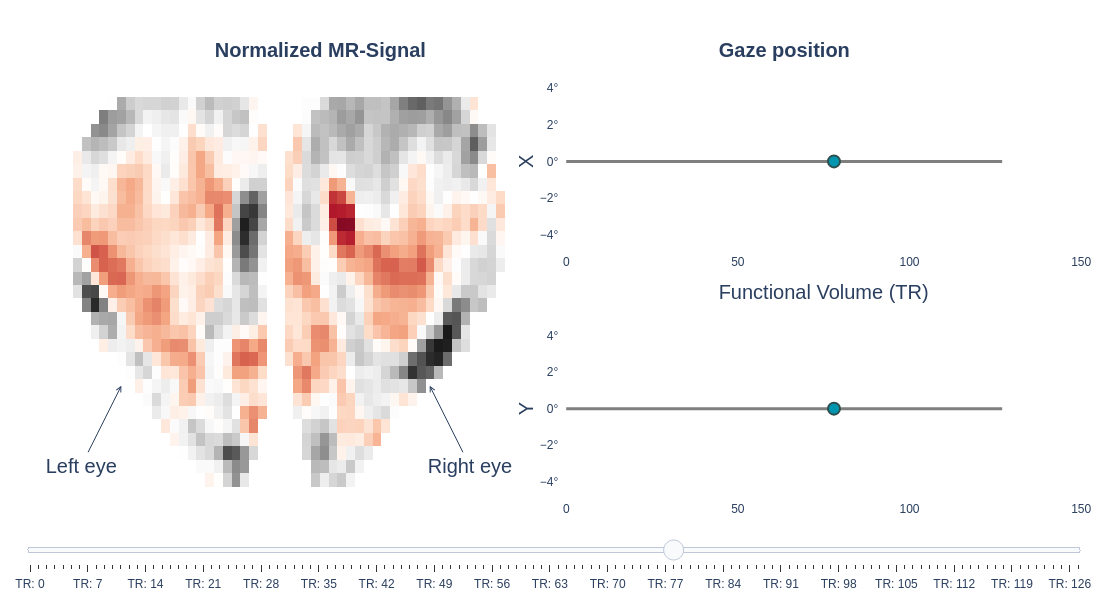

In [11]:
fig = analyse.visualise_input_data(X, y, bg_color="rgb(255,255,255)", ylim=[-5, 5])
fig.show()